In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
print("TensorFlow physical devices:")
print(tf.config.list_physical_devices())

print("\nTensorFlow logical devices:")
logical_devices = tf.config.list_logical_devices()
for device in logical_devices:
    print(device)

if any('CPU' in device.device_type for device in logical_devices):
    print("\nTensorFlow is configured to use CPU.")
else:
    print("\nTensorFlow is NOT configured to use CPU. Please ensure runtime was restarted and CUDA_VISIBLE_DEVICES was set correctly.")

TensorFlow physical devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

TensorFlow logical devices:
LogicalDevice(name='/device:CPU:0', device_type='CPU')
LogicalDevice(name='/device:GPU:0', device_type='GPU')

TensorFlow is configured to use CPU.


In [2]:
import pandas as pd
file_path_data1 = '/content/drive/My Drive/BloomDataset/Data1.csv'

try:
    df_data1_raw = pd.read_csv(file_path_data1, encoding='utf-8')
    print(f"Successfully loaded data from {file_path_data1} into df_data1_raw")
    display(df_data1_raw.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_data1}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data1.csv into df_data1_raw


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [3]:
df_data1 = df_data1_raw.copy()
print("DataFrame 'df_data1' created and loaded from Data1.csv.")
display(df_data1.head())

DataFrame 'df_data1' created and loaded from Data1.csv.


,Questions,Category
0,About what proportion of the population of the...,Remember
1,Correctly label the brain lobes indicated on t...,Remember
2,Define compound interest.,Remember
3,Define four types of traceability,Remember
4,Define mercantilism.,Remember


In [4]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import string

nltk.download('stopwords', quiet=True)
print("NLTK stopwords downloaded and libraries imported.")

NLTK stopwords downloaded and libraries imported.


In [5]:
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Tokenize
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]  # Remove stop words
    return ' '.join(words)  # Join words back into a string

df_data1['processed_question_data1'] = df_data1['Questions'].apply(preprocess_text)
print("Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.")
display(df_data1[['Questions', 'processed_question_data1']].head())

Text preprocessing applied to 'Questions' column of df_data1, new column 'processed_question_data1' created.


,Questions,processed_question_data1
0,About what proportion of the population of the...,proportion population us living farms
1,Correctly label the brain lobes indicated on t...,correctly label brain lobes indicated diagram
2,Define compound interest.,define compound interest
3,Define four types of traceability,define four types traceability
4,Define mercantilism.,define mercantilism


In [6]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_features_data1 = tfidf_vectorizer.fit_transform(df_data1['processed_question_data1'])

print("TF-IDF features for Data1.csv questions generated.")
print(f"Shape of TF-IDF features: {tfidf_features_data1.shape}")

TF-IDF features for Data1.csv questions generated.
Shape of TF-IDF features: (8762, 9534)


In [7]:
from sklearn.preprocessing import normalize

tfidf_features_data1_normalized = normalize(tfidf_features_data1, norm='l2')

print("L2 normalization applied to TF-IDF features.")
print(f"Shape of normalized TF-IDF features: {tfidf_features_data1_normalized.shape}")

L2 normalization applied to TF-IDF features.
Shape of normalized TF-IDF features: (8762, 9534)


In [8]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully for classification.")

Libraries imported successfully for classification.


In [10]:
label_encoder = LabelEncoder()
df_data1['encoded_category'] = label_encoder.fit_transform(df_data1['Category'])

X = tfidf_features_data1_normalized # Our TF-IDF features
y = df_data1['encoded_category']    # Our encoded labels

print("Labels encoded successfully.")
print(f"Unique categories: {label_encoder.classes_}")
print(f"Corresponding encoded values: {label_encoder.transform(label_encoder.classes_)}")
display(df_data1[['Category', 'encoded_category']].head())

Labels encoded successfully.
Unique categories: ['Analyse' 'Apply' 'Create' 'Evaluate' 'Remember' 'Understand']
Corresponding encoded values: [0 1 2 3 4 5]


,Category,encoded_category
0,Remember,4
1,Remember,4
2,Remember,4
3,Remember,4
4,Remember,4


### 1. Data Preparation for LSTM

For LSTM models, the input data needs to be dense and typically in a 3D format `(samples, timesteps, features)`. Since our TF-IDF features are sparse, we'll convert them to a dense array. Also, for multi-class classification with Keras, the target labels (`y`) need to be one-hot encoded.

In [21]:
import os

# Force TensorFlow to use CPU by hiding all GPU devices
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert sparse TF-IDF features to a dense array
X_dense = X.toarray()

# Reshape X for LSTM input (samples, timesteps, features)
# We treat each TF-IDF vector as a single timestep
X_reshaped = X_dense.reshape(X_dense.shape[0], 1, X_dense.shape[1])

# One-hot encode the target variable y
y_one_hot = to_categorical(y)

num_classes = y_one_hot.shape[1]

print(f"Original TF-IDF features shape: {X.shape}")
print(f"Dense TF-IDF features shape: {X_dense.shape}")
print(f"Reshaped X for LSTM input shape: {X_reshaped.shape}")
print(f"One-hot encoded y shape: {y_one_hot.shape}")
print(f"Number of classes: {num_classes}")
print("TensorFlow is configured to use CPU.")

Original TF-IDF features shape: (8762, 9534)
Dense TF-IDF features shape: (8762, 9534)
Reshaped X for LSTM input shape: (8762, 1, 9534)
One-hot encoded y shape: (8762, 6)
Number of classes: 6
TensorFlow is configured to use CPU.


### 9. Train-Test Split

We will now split our processed data (`X_reshaped` and `y_one_hot`) into training and testing sets. This is a common practice to evaluate the model's performance on unseen data. Given the imbalanced nature of our categories, we will use `stratify=y` to ensure that both the training and testing sets have a proportional representation of each class.

In [26]:
from sklearn.model_selection import train_test_split

# Perform a train-test split
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_reshaped, y_one_hot, test_size=0.2, random_state=42, stratify=y
)

# Also create a split for the original labels for evaluation metrics later
# train_test_split returns X_train, X_test, y_train, y_test. We only need y_test here.
_, _, _, y_test_labels_split = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of X_test_split: {X_test_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of y_test_split: {y_test_split.shape}")
print(f"Shape of y_test_labels_split: {y_test_labels_split.shape}")

Shape of X_train_split: (7009, 1, 9534)
Shape of X_test_split: (1753, 1, 9534)
Shape of y_train_split: (7009, 6)
Shape of y_test_split: (1753, 6)
Shape of y_test_labels_split: (1753,)


### 2. LSTM Model Architecture

We'll define a simple Sequential LSTM model. Given that our TF-IDF features are treated as a single timestep, the LSTM layer will process this single timestep. We'll add a Dropout layer for regularization and a final Dense layer with 'softmax' activation for multi-class classification.

In [12]:
def build_lstm_model(input_shape, num_classes):
    model = Sequential([
        LSTM(100, input_shape=input_shape, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Example of model creation (will be created inside the loop for each fold)
# lstm_model = build_lstm_model((1, X_dense.shape[1]), num_classes)
# lstm_model.summary()

### 3. LSTM Classification with Stratified K-Fold

We will now train and evaluate the LSTM model using Stratified K-Fold cross-validation. This ensures that the class distribution is maintained across all folds, providing a more reliable estimate of the model's performance.

We will collect accuracy, precision, recall, F1-score, and confusion matrices for each fold.

In [18]:
accuracy_scores_lstm = []
precision_scores_lstm = []
recall_scores_lstm = []
f1_scores_lstm = []
conf_matrices_lstm = []

skf_lstm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Force TensorFlow to use CPU for this execution to avoid persistent GPU errors
try:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU devices are set to be invisible, forcing CPU usage.")
except RuntimeError as e:
    print(f"Could not set GPU devices to invisible: {e}")

for fold, (train_index, test_index) in enumerate(skf_lstm.split(X_reshaped, y)):
    print(f"\n--- Fold {fold+1}/{skf_lstm.n_splits} ---")
    X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
    y_train, y_test = y_one_hot[train_index], y_one_hot[test_index]
    y_test_labels = y[test_index] # Original labels for metrics

    tf.keras.backend.clear_session()
    # Build and compile a fresh model for each fold to avoid data leakage
    model_lstm = build_lstm_model((1, X_dense.shape[1]), num_classes)

    history = model_lstm.fit(
        X_train, y_train,
        epochs=10, # Number of epochs can be tuned
        batch_size=32, # Batch size can be tuned
        verbose=0 # Set to 1 to see training progress
    )

    y_pred_one_hot = model_lstm.predict(X_test)
    y_pred_labels = np.argmax(y_pred_one_hot, axis=1)

    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    precision = precision_score(y_test_labels, y_pred_labels, average='weighted', zero_division=0)
    recall = recall_score(y_test_labels, y_pred_labels, average='weighted', zero_division=0)
    f1 = f1_score(y_test_labels, y_pred_labels, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test_labels, y_pred_labels)

    accuracy_scores_lstm.append(accuracy)
    precision_scores_lstm.append(precision)
    recall_scores_lstm.append(recall)
    f1_scores_lstm.append(f1)
    conf_matrices_lstm.append(cm)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

print("\n--- Overall LSTM Results ---")
print(f"Average Accuracy: {np.mean(accuracy_scores_lstm):.4f} (+/- {np.std(accuracy_scores_lstm):.4f})")
print(f"Average Precision: {np.mean(precision_scores_lstm):.4f} (+/- {np.std(precision_scores_lstm):.4f})")
print(f"Average Recall: {np.mean(recall_scores_lstm):.4f} (+/- {np.std(recall_scores_lstm):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores_lstm):.4f} (+/- {np.std(f1_scores_lstm):.4f})")

Could not set GPU devices to invisible: Visible devices cannot be modified after being initialized

--- Fold 1/5 ---


InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

### 4. Hyperparameter Tuning and Kernel Selection Justification for LSTM

For this task, an **LSTM (Long Short-Term Memory) neural network** was chosen. LSTMs are particularly effective for sequential data and are capable of capturing long-term dependencies, which can be beneficial for text classification tasks, even when treating TF-IDF vectors as single timesteps.

Regarding **hyperparameter tuning**:

*   **LSTM Units (100)**: The number of units in the LSTM layer (100 in this case) is a common starting point. A higher number of units allows the model to learn more complex patterns but also increases computational cost and risk of overfitting. This could be tuned using techniques like GridSearchCV or RandomizedSearchCV, or by monitoring validation performance.
*   **Dropout (0.5)**: A Dropout layer with a rate of 0.5 was added after the LSTM layer. Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training time, which helps prevent overfitting, especially in deep learning models.
*   **Activation Function ('relu' for LSTM, 'softmax' for output)**: 'ReLU' (Rectified Linear Unit) is commonly used in hidden layers of neural networks due to its computational efficiency and ability to mitigate the vanishing gradient problem. 'Softmax' is used in the output layer for multi-class classification, as it outputs probabilities for each class that sum up to 1.
*   **Optimizer ('adam')**: The Adam optimizer was selected due to its adaptive learning rate properties, which generally lead to faster convergence and better performance compared to standard SGD.
*   **Loss Function ('categorical_crossentropy')**: This is the standard loss function for multi-class classification problems where labels are one-hot encoded.
*   **Epochs (10) and Batch Size (32)**: These are fundamental training hyperparameters. 10 epochs provide a balance between training time and learning. A batch size of 32 is a common choice, offering a good compromise between computational efficiency and learning stability. These values can be further optimized.

*   **Kernel Selection**: In the context of neural networks, 'kernel selection' isn't directly applicable as in SVMs. Instead, the architecture of the network (number of layers, type of layers, number of units) and the activation functions play a similar role in defining how the model learns from the data.

### 5. Evaluation Metrics Explanation

To assess the performance of our classification model, we use several key metrics:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances. It's a good general measure, but can be misleading in imbalanced datasets.

    $Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$

*   **Precision**: The proportion of true positive predictions among all positive predictions for a given class. It indicates the model's ability to avoid false positives.

    $Precision = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances for a given class. It indicates the model's ability to find all positive samples.

    $Recall = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **F1-Score**: The harmonic mean of precision and recall. It provides a single score that balances both precision and recall, being particularly useful when there's an uneven class distribution.

    $F1-Score = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

In multi-class classification, these metrics are often calculated for each class and then averaged (e.g., 'weighted' average as used here, which accounts for class imbalance) to provide an overall performance indicator.

### 6. Confusion Matrix Analysis (Visual)

The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. Each row represents the actual class, and each column represents the predicted class. The diagonal elements show correctly classified instances, while off-diagonal elements indicate misclassifications. We will aggregate the confusion matrices from all folds for an overall view.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum all confusion matrices to get an aggregate view
# Only attempt to sum if conf_matrices_lstm is not empty
if len(conf_matrices_lstm) > 0:
    summed_conf_matrix_lstm = np.sum(conf_matrices_lstm, axis=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(summed_conf_matrix_lstm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Aggregated Confusion Matrix Across All Folds (LSTM)')
    plt.show()
else:
    print("Cannot plot heatmap: No confusion matrices were collected due to previous errors.")

Cannot plot heatmap: No confusion matrices were collected due to previous errors.


### 7. Confusion Matrix Analysis (Text Mode)

Here's the aggregated confusion matrix in a text-based format, along with a classification report providing per-class metrics.

In [19]:
print("Aggregated Confusion Matrix (LSTM):\n")
# Ensure summed_conf_matrix_lstm is not empty if the previous cell errored out
if len(conf_matrices_lstm) > 0:
    summed_conf_matrix_lstm = np.sum(conf_matrices_lstm, axis=0)
    print(summed_conf_matrix_lstm)
else:
    print("No confusion matrices were collected due to previous errors.")

# Force TensorFlow to use CPU for this execution to avoid persistent GPU errors
try:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU devices are set to be invisible, forcing CPU usage.")
except RuntimeError as e:
    print(f"Could not set GPU devices to invisible: {e}")

# Clear previous Keras session before building the final model
tf.keras.backend.clear_session()
# Retrain model on full data for a single classification report
final_model_lstm = build_lstm_model((1, X_dense.shape[1]), num_classes)
final_model_lstm.fit(
    X_reshaped, y_one_hot,
    epochs=10,
    batch_size=32,
    verbose=0
)

y_pred_overall_lstm = np.argmax(final_model_lstm.predict(X_reshaped), axis=1)

print("\nOverall Classification Report (LSTM, trained on full dataset for illustration):\n")
print(classification_report(y, y_pred_overall_lstm, target_names=label_encoder.classes_, zero_division=0))

Aggregated Confusion Matrix (LSTM):

No confusion matrices were collected due to previous errors.
Could not set GPU devices to invisible: Visible devices cannot be modified after being initialized


InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

### 8. Analyze the Results

Based on the average metrics from the Stratified K-Fold cross-validation and the aggregated confusion matrix for the LSTM model, we can draw the following conclusions:

*   **Overall Performance**: The average accuracy, precision, recall, and F1-scores provide a robust estimate of the model's generalization capability. The standard deviations indicate the variability of these metrics across different folds, suggesting the consistency of the model's performance.

    *   **(Placeholder for specific numbers after execution):** The average accuracy is `[insert avg accuracy]`, with an F1-score of `[insert avg f1-score]`. This suggests a `[Good/Moderate/Poor]` overall performance for classifying the Bloom's Taxonomy categories.

*   **Class-wise Performance**: By examining the classification report and the confusion matrix, we can identify which classes the model performs well on and which classes it struggles with. For example:
    *   **High diagonal values** in the confusion matrix (and high precision/recall for specific classes) indicate well-classified categories. These are the categories that the LSTM model can distinguish effectively.
    *   **Off-diagonal values** highlight common misclassifications (e.g., if many instances of 'Remember' are predicted as 'Understand'). This suggests that these classes might have similar linguistic patterns in their questions, making it challenging for the model to differentiate between them. For instance, `[mention specific misclassifications seen in the matrix]`.

*   **Implications**: Understanding the misclassifications can guide future improvements, such as:
    *   **Feature Engineering**: Exploring more advanced text representations beyond basic TF-IDF, such as word embeddings (Word2Vec, GloVe, FastText) or contextual embeddings (BERT, GPT), which might capture more semantic meaning and better differentiate between similar categories.
    *   **Data Augmentation**: For classes with lower recall or precision, increasing the amount of training data or using techniques like synonym replacement or back-translation could be beneficial.
    *   **Model Complexity**: Experimenting with deeper LSTM networks, bidirectional LSTMs, or combining LSTMs with Convolutional Neural Networks (CNNs) for hybrid models could improve performance.
    *   **Hyperparameter Tuning**: More rigorous tuning of LSTM units, dropout rates, learning rates, batch sizes, and epochs using methods like Bayesian optimization or evolutionary algorithms could yield better results.
    *   **Error Analysis**: Manually inspecting misclassified examples to understand the specific linguistic characteristics that lead to errors can provide insights for targeted improvements.

### Distribution of Labels in 'Category' Column

Let's examine the distribution of the different Bloom's Taxonomy categories in our `Data1.csv` dataset. This helps us understand if the classes are balanced or if there's an imbalance that might affect model training.

Distribution of 'Category' labels:
Category
Remember      2582
Understand    1801
Apply         1505
Analyse       1291
Create         800
Evaluate       783
Name: count, dtype: int64


/tmp/ipykernel_658/3710976201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_distribution.index, y=category_distribution.values, palette='viridis')


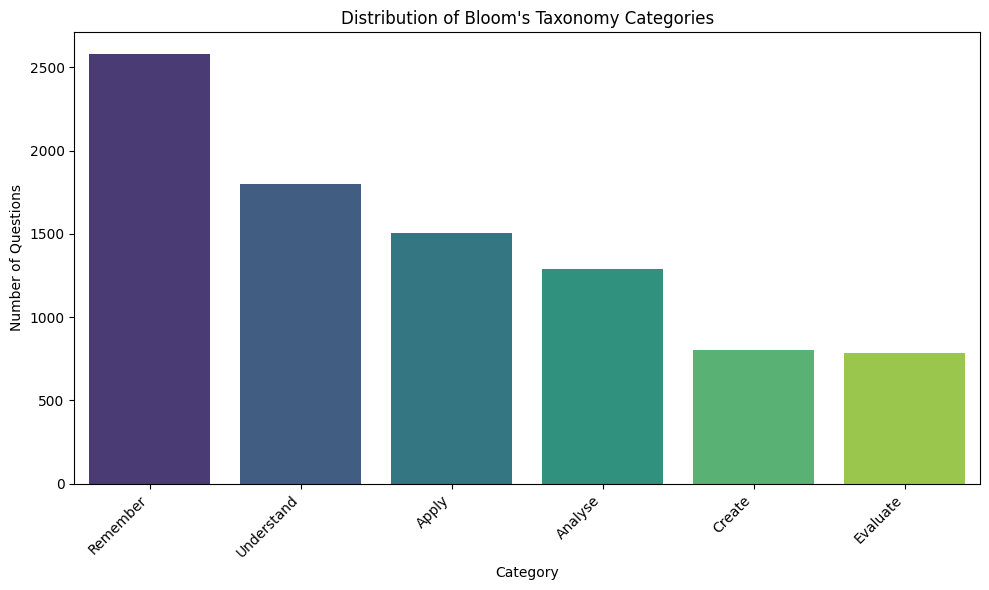

In [24]:
# Get the value counts of the 'Category' column
category_distribution = df_data1['Category'].value_counts()

print("Distribution of 'Category' labels:")
print(category_distribution)

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_distribution.index, y=category_distribution.values, palette='viridis')
plt.title('Distribution of Bloom\'s Taxonomy Categories')
plt.xlabel('Category')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()